In [1]:
# Cheatsheet — three densities (regular / extra / super).
# Dotted background (shares DOT_SIZES with dotted) plus TWO vertical
# dividers splitting the page into three columns. Divider positions are
# chosen per density so each divider is centered on the midpoint between
# adjacent dot columns at the section boundary — the cleanest visual fit.
#
# 3-column dot splits (symmetric around page center):
#   regular: 11 / 12 / 11     dividers at x-centers 2750, 5750
#   extra:   19 / 18 / 19     dividers at x-centers 2900, 5600
#   super:   22 / 23 / 22     dividers at x-centers 2812.5, 5687.5
# Middle section has one extra dot column; visual widths:
#   regular: 2635 / 3000 / 2634  (middle +365 px)
#   extra:   2781 / 2700 / 2780  (middle -81 px)
#   super:   2693 / 2875 / 2692  (middle +182 px)
#
# Divider LINE_WIDTH matches graph's scheme (10/6/4) so the divider
# weight scales with density. `left_x` is chosen so the line straddles
# the dot-gap midpoint as symmetrically as possible (some densities have
# a 0.5 px drift due to even-width line on integer midpoint; invisible).
#
# Dividers run from the header's bottom edge down to the bottom-margin
# edge of the usable area — the full writing zone height.
#
# Output: ../output/cheatsheet/{cheatsheet,extra-cheatsheet,super-cheatsheet}.png
from PIL import Image
from IPython.display import display
from common import (
    blank_page, draw_header, make_dot_template, vline, edge_margin,
    HEADER_HEIGHT, HEIGHT,
    grid_counts, lattice_x, lattice_y,
    output_path, variant_name, DENSITIES,
)

MODE = "cheatsheet"

DOT_SIZES = {           # same as dotted
    "regular": 20,
    "extra":   12,
    "super":   10,
}
LINE_WIDTHS = {         # same as graph
    "regular": 10,
    "extra":   6,
    "super":   4,
}
# Divider left_x (top-left pixel of the thick line) per density. Chosen so
# the line center sits on or next to the dot-gap midpoint.
DIVIDERS = {
    "regular": [2745, 5745],   # centers 2749.5, 5749.5 (target 2750, 5750)
    "extra":   [2897, 5597],   # centers 2899.5, 5599.5 (target 2900, 5600)
    "super":   [2811, 5686],   # centers 2812.5, 5687.5 exact
}

In [2]:
def render_cheatsheet(spacing, dot_size, line_width, divider_xs):
    """Stamp a dotted lattice and draw two vertical column dividers."""
    dot = make_dot_template(size=dot_size)
    img = blank_page()
    n_x, n_y = grid_counts(spacing)
    for i in range(n_x):
        x = lattice_x(i, spacing, dot_size)
        for j in range(n_y):
            img.paste(dot, (x, lattice_y(j, spacing, dot_size)))
    # Dividers span header-bottom to bottom-margin of the usable area.
    div_bottom = HEIGHT - 1 - edge_margin(line_width)
    for left_x in divider_xs:
        vline(img, left_x, thickness=line_width,
              top=HEADER_HEIGHT, bottom=div_bottom)
    draw_header(img)
    return img, n_x, n_y

regular  spacing=250  dot=20  lw=10  34×43 dots  dividers=[2745, 5745]  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/cheatsheet/cheatsheet.png


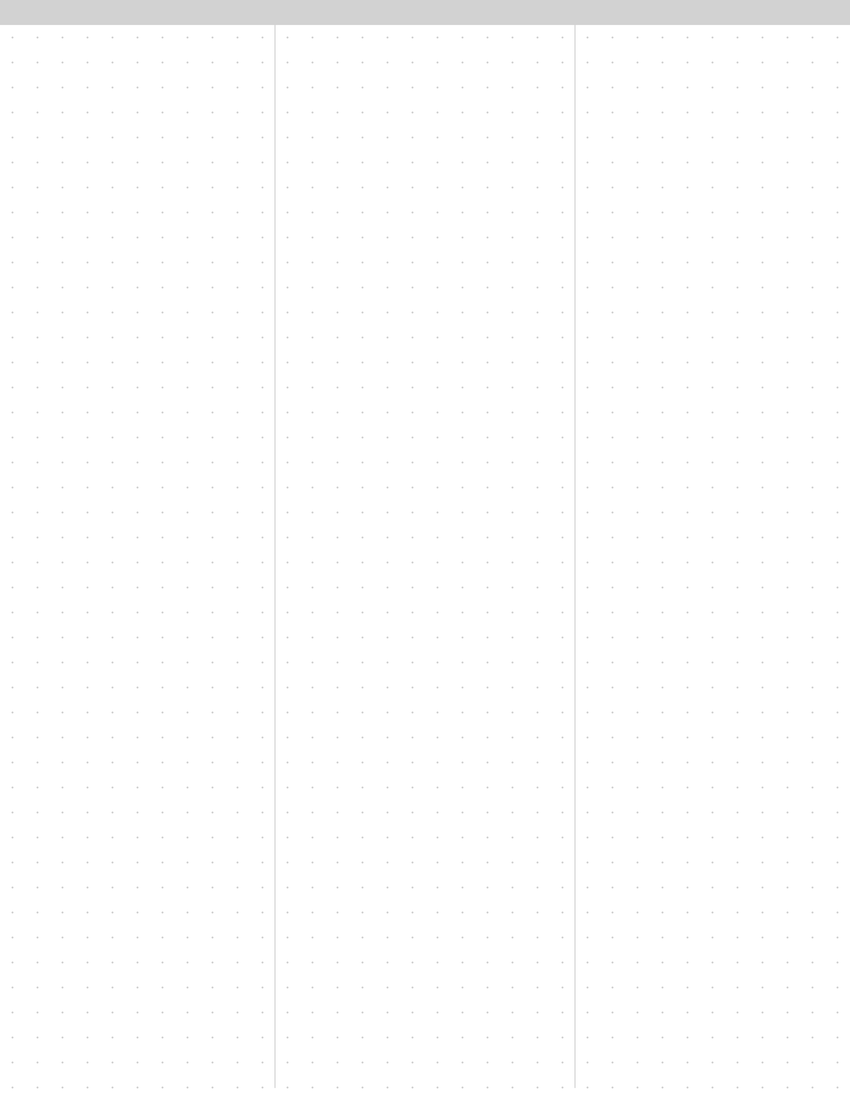

extra    spacing=150  dot=12  lw= 6  56×71 dots  dividers=[2897, 5597]  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/cheatsheet/extra-cheatsheet.png


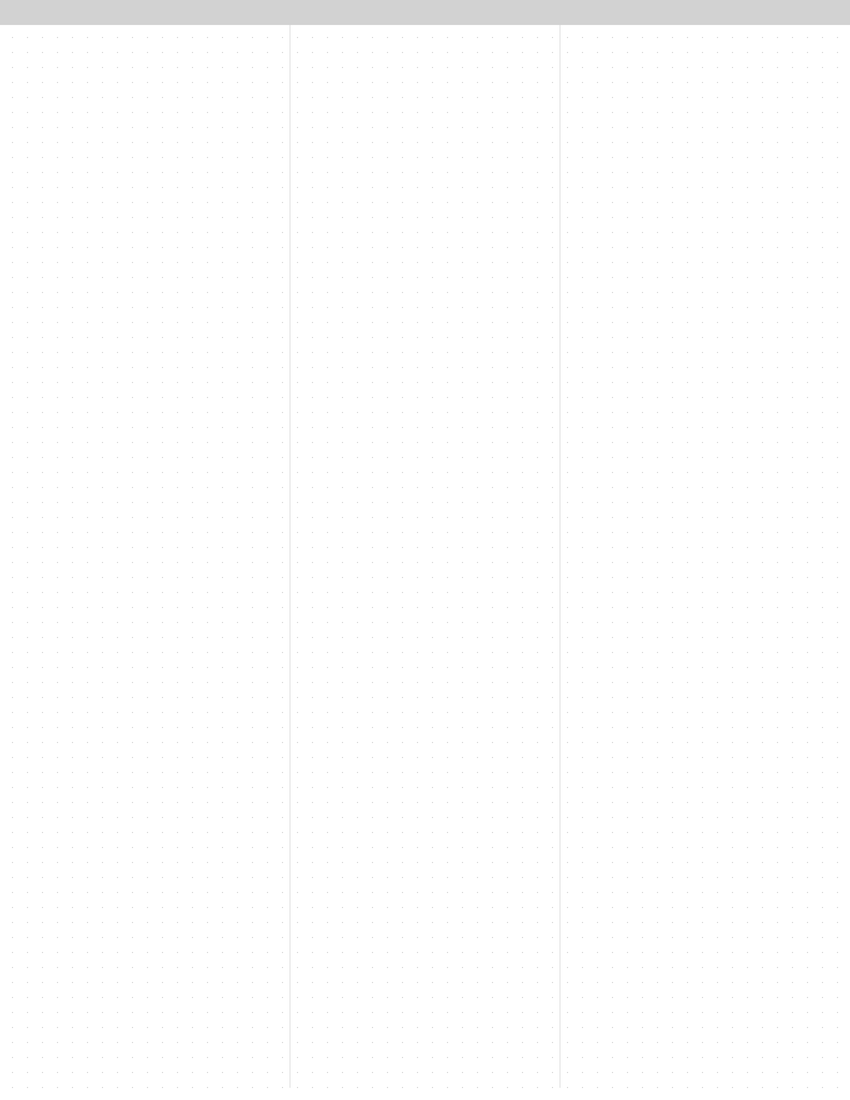

super    spacing=125  dot=10  lw= 4  67×85 dots  dividers=[2811, 5686]  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/cheatsheet/super-cheatsheet.png


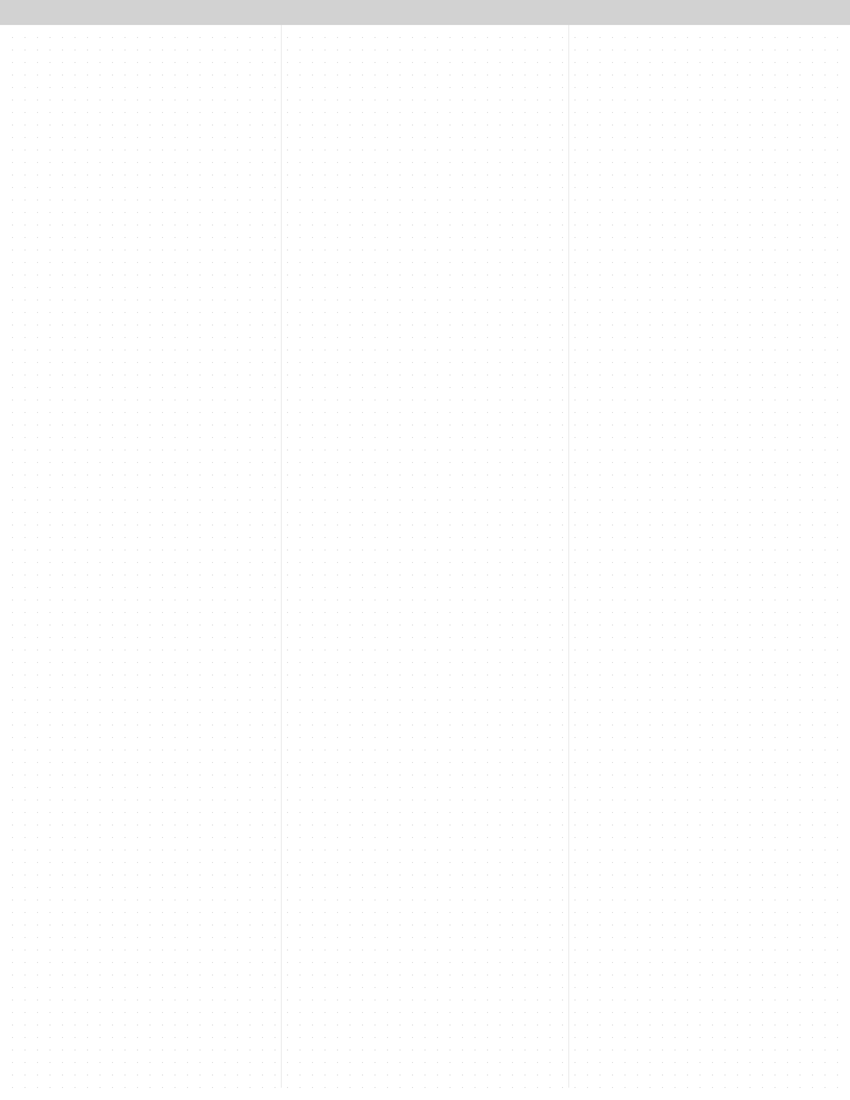

In [3]:
for density, spacing in DENSITIES.items():
    dot_size = DOT_SIZES[density]
    lw       = LINE_WIDTHS[density]
    divs     = DIVIDERS[density]
    img, n_x, n_y = render_cheatsheet(spacing, dot_size, lw, divs)
    path = output_path(MODE, variant_name(MODE, density))
    img.save(path, "PNG")
    print(
        f"{density:8s} spacing={spacing:3d}  dot={dot_size:2d}  lw={lw:2d}  "
        f"{n_x}×{n_y} dots  dividers={divs}  →  {path}"
    )
    display(img.resize((850, 1100), Image.LANCZOS))